# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [23]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [24]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [ ]:
PARENT = Path("/home/vse23/Projects/pypsa-earth")

config_path = PARENT / "config_NZ.yaml"
config = yaml.safe_load(config_path.read_text())

# Main solved postnetwork (with site-specific UHS)
postnetwork_name = "elec_s_16_ec_lcopt_Co2L0.40-1h_1h_2030_0.071.nc"
results_path = PARENT / "results" / "postnetworks" / postnetwork_name

# Frozen baseline created before adding Ahuroa.
# The comparison section below is automatically skipped if this file is absent.
baseline_path = results_path.with_name(results_path.stem + "_BASE.nc")

# Other model inputs used by the original analysis
scenario_name = config["run"]["name"]
network_path = PARENT / "networks" / "NZ-DryYear2012" / "elec.nc"
regions_onshore_path = PARENT / "resources" / "NZ-DryYear2012" / "shapes" / "country_shapes.geojson"
solar_path = PARENT / "resources" / "NZ-DryYear2012" / "renewable_profiles" / "profile_solar.nc"
onwind_path = PARENT / "resources" / "NZ-DryYear2012" / "renewable_profiles" / "profile_onwind.nc"

print(f"UHS result: {results_path}")
print(f"Baseline:   {baseline_path} ({'found' if baseline_path.exists() else 'not found'})")

UHS result: /home/vse23/Projects/pypsa-earth/results/postnetworks/elec_s_16_ec_lcopt_Co2L0.40-1h_1h_2030_0.071.nc
Baseline:   /home/vse23/Projects/pypsa-earth/results/postnetworks/elec_s_16_ec_lcopt_Co2L0.40-1h_1h_2030_0.071.nc (found)


## Energy system analysis setup - power and energy generation

In [26]:
warnings.simplefilter(action="ignore", category=FutureWarning)

n = pypsa.Network(str(results_path))
regions_onshore = gpd.read_file(str(regions_onshore_path))

from shapely.geometry import box
try:
    from shapely.validation import make_valid
except ImportError:
    make_valid = None

nz_extent = [166.0, 179.0, -48.5, -33.5]

def clean_geometries(gdf, bbox=None):
    """Clean geometries for robust plotting with Cartopy."""
    gdf = gdf.copy()

    if gdf.crs is not None:
        gdf = gdf.to_crs("EPSG:4326")

    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    def _fix(geom):
        if geom is None or geom.is_empty:
            return geom
        try:
            if make_valid is not None:
                geom = make_valid(geom)
            elif not geom.is_valid:
                geom = geom.buffer(0)
        except Exception:
            try:
                geom = geom.buffer(0)
            except Exception:
                return None
        return geom

    gdf["geometry"] = gdf.geometry.apply(_fix)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    # For NZ maps, clipping avoids antimeridian/island geometries that can
    # trigger GEOS/Cartopy LinearRing errors during projection.
    if bbox is not None:
        clip_geom = box(bbox[0], bbox[2], bbox[1], bbox[3])
        gdf["geometry"] = gdf.geometry.apply(
            lambda geom: geom.intersection(clip_geom) if geom is not None else None
        )
        gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    return gdf

regions_plot = clean_geometries(regions_onshore, nz_extent)
country_coordinates = nz_extent

warnings.simplefilter(action="default", category=FutureWarning)

print(f"Objective: {n.objective:,.2f}")
print(f"Snapshots: {len(n.snapshots):,}")
print(f"Region geometries available for plotting: {len(regions_plot)}")

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L0.40-1h_1h_2030_0.071.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Objective: 3,634,093,215.77
Snapshots: 8,760
Region geometries available for plotting: 1


## Data import check

Plot of the region of interest

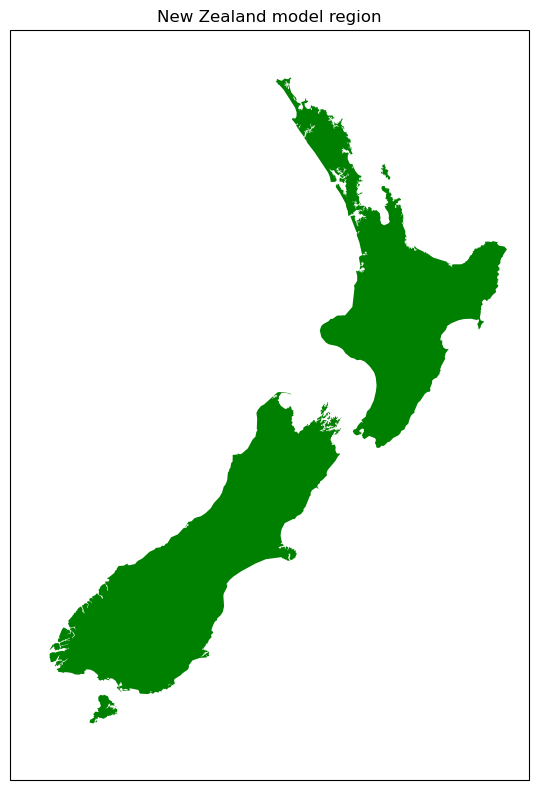

In [27]:
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.EqualEarth(174.0)},
)

with plt.rc_context({"patch.linewidth": 0.}):
    regions_plot.plot(
        ax=ax,
        facecolor="green",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0,
    )

ax.set_extent(nz_extent, crs=ccrs.PlateCarree())
ax.set_title("New Zealand model region")
fig.tight_layout()

List number of components by type

In [28]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 164 entries
Component 'Carrier' has 43 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 18 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 228 entries
Component 'Load' has 17 entries
Component 'Generator' has 117 entries
Component 'StorageUnit' has 22 entries
Component 'Store' has 131 entries


List the snapshots of the PyPSA network

In [29]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 01:00:00',
               '2012-01-01 02:00:00', '2012-01-01 03:00:00',
               '2012-01-01 04:00:00', '2012-01-01 05:00:00',
               '2012-01-01 06:00:00', '2012-01-01 07:00:00',
               '2012-01-01 08:00:00', '2012-01-01 09:00:00',
               ...
               '2012-12-30 14:00:00', '2012-12-30 15:00:00',
               '2012-12-30 16:00:00', '2012-12-30 17:00:00',
               '2012-12-30 18:00:00', '2012-12-30 19:00:00',
               '2012-12-30 20:00:00', '2012-12-30 21:00:00',
               '2012-12-30 22:00:00', '2012-12-30 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)
Time steps: 8760


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


ValueError: Axis limits cannot be NaN or Inf

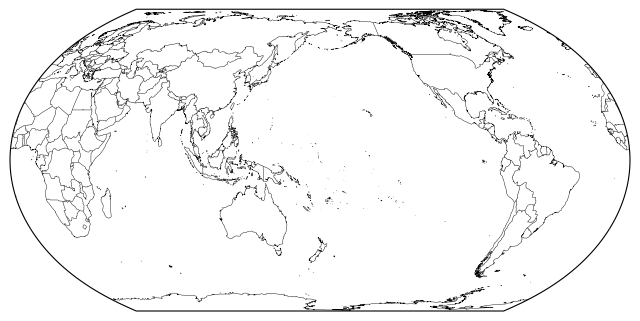

In [30]:
# Scale settings
bus_scale = 6e3
line_scale = 6e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# Fixed NZ extent: a tight crop around the country to avoid showing the whole planet
nz_extent = [166.0, 179.0, -48.5, -33.5]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(174.0)})

# use only real generation/storage buses and keep the spatial focus on NZ
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.02,
        color_geomap=None,
    )

regions_plot.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(nz_extent, crs=ccrs.PlateCarree())

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

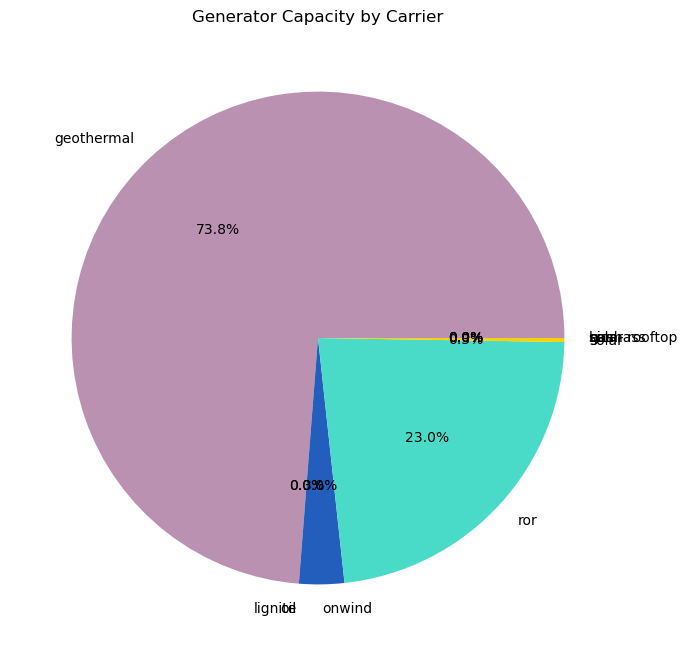

In [31]:
generator_capacity_by_carrier = (
    n.generators[n.generators.carrier != "load"]
    .groupby(["carrier"])
    .p_nom.sum()
)
plt.figure(figsize=(8, 8))
plt.pie(
    generator_capacity_by_carrier,
    labels=generator_capacity_by_carrier.index,
    autopct='%1.1f%%',
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
plt.title("Generator Capacity by Carrier")

Analyse the current generation capacity of the energy system - tabular view

In [32]:
generator_capacity_by_carrier/1e3 # in GW

carrier
biomass          0.00000
coal             0.00000
gas              0.00000
geothermal       1.07300
lignite          0.00000
oil              0.00000
onwind           0.04300
ror              0.33488
solar            0.00380
solar rooftop    0.00000
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


ValueError: Axis limits cannot be NaN or Inf

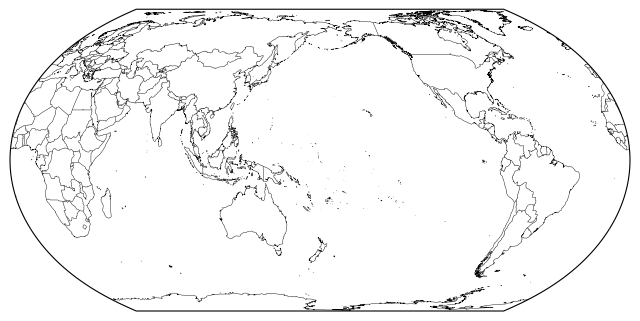

In [33]:
# Fixed NZ extent: a tight crop around the country to avoid showing the whole planet
nz_extent = [166.0, 179.0, -48.5, -33.5]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(174.0)})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.02,
        color_geomap=None,
    )
regions_plot.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(nz_extent, crs=ccrs.PlateCarree())
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)
fig.tight_layout()

Analyse the future generation capacity expansion of the energy system - bar chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

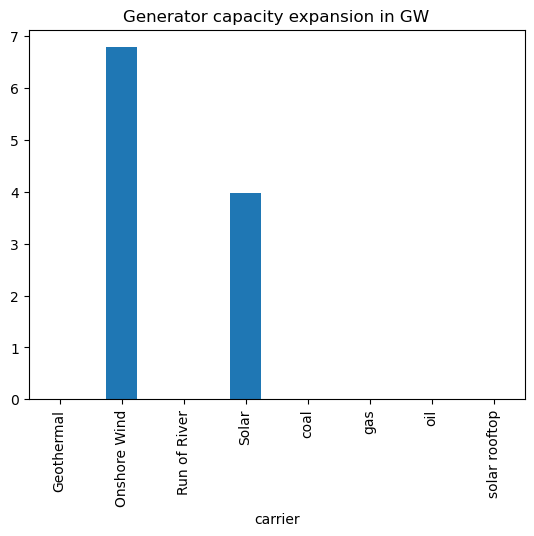

In [34]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
#generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [35]:
generation_capacity_expansion # In GW

carrier
Geothermal       0.000000
Onshore Wind     6.785625
Run of River     0.000000
Solar            3.969418
coal                  NaN
gas                   NaN
oil                   NaN
solar rooftop         NaN
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

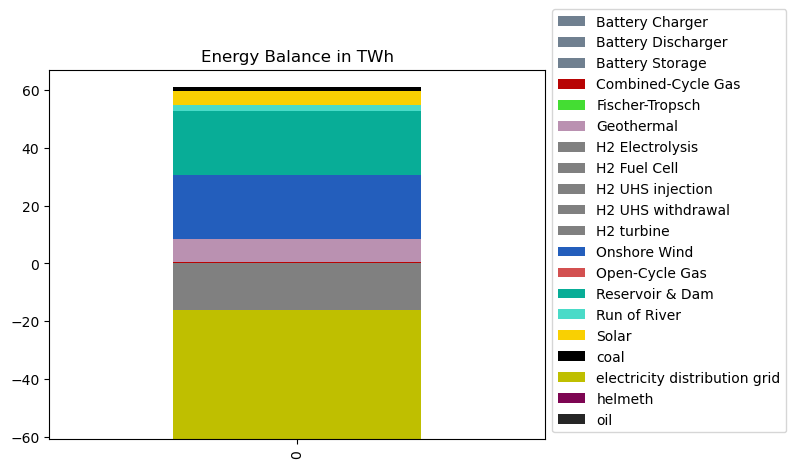

In [36]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [37]:
n.statistics.energy_balance()/1e6 # In TWh

component  carrier                  bus_carrier 
Store      Battery Storage          battery         6.420811e-10
           H2 Store Tank            H2              1.091474e-17
           H2 UHS                   H2             -1.470544e-08
           co2                      co2            -1.416091e+00
           co2 stored               co2 stored     -4.190688e-09
                                                        ...     
Link       home battery discharger  home battery   -9.073166e-03
                                    low voltage     8.889851e-03
           oil                      AC              1.940159e-03
                                    co2             1.425185e-03
                                    oil            -5.543312e-03
Length: 66, dtype: float64

## Underground hydrogen storage (Ahuroa)

This section validates the site-specific UHS implementation and analyses its investment and operation.  
It reports optimized storage and injection/withdrawal capacities, annual hydrogen throughput, compression electricity use, equivalent cycles, and the seasonal state-of-charge profile.

The baseline comparison is optional and uses the frozen `_BASE.nc` file if it is available.

In [38]:
# Identify site-specific UHS components
uhs_stores = n.stores.index[n.stores.carrier.eq("H2 UHS")]
uhs_injection = n.links.index[n.links.carrier.eq("H2 UHS injection")]
uhs_withdrawal = n.links.index[n.links.carrier.eq("H2 UHS withdrawal")]

print("UHS stores:", list(uhs_stores))
print("Injection links:", list(uhs_injection))
print("Withdrawal links:", list(uhs_withdrawal))

if len(uhs_stores) == 0:
    raise RuntimeError("No site-specific UHS store was found in this network.")

uhs_components = pd.concat(
    {
        "Store": n.stores.loc[
            uhs_stores,
            ["bus", "carrier", "e_nom_opt", "e_nom_max", "capital_cost"],
        ].rename(columns={"e_nom_opt": "capacity_opt", "e_nom_max": "capacity_max"}),
        "Injection link": n.links.loc[
            uhs_injection,
            ["bus0", "bus1", "bus2", "carrier", "p_nom_opt", "p_nom_max", "capital_cost"],
        ].rename(columns={"p_nom_opt": "capacity_opt", "p_nom_max": "capacity_max"}),
        "Withdrawal link": n.links.loc[
            uhs_withdrawal,
            ["bus0", "bus1", "bus2", "carrier", "p_nom_opt", "p_nom_max", "capital_cost"],
        ].rename(columns={"p_nom_opt": "capacity_opt", "p_nom_max": "capacity_max"}),
    },
    names=["component_type", "name"],
)

uhs_components

UHS stores: ['NZ_AHUROA H2 UHS']
Injection links: ['NZ_AHUROA H2 injection']
Withdrawal links: ['NZ_AHUROA H2 withdrawal']


,,bus,carrier,capacity_opt,capacity_max,capital_cost,bus0,bus1,bus2
component_type,name,,,,,,,,
Store,NZ_AHUROA H2 UHS,NZ_AHUROA UHS,H2 UHS,195169.258970,1500000.0,43.2308,NaN,NaN,NaN
Injection link,NZ_AHUROA H2 injection,NaN,H2 UHS injection,88.995399,500.0,17292.3072,NZ.15_1_AC H2,NZ_AHUROA UHS,NZ.15_1_AC
Withdrawal link,NZ_AHUROA H2 withdrawal,NaN,H2 UHS withdrawal,198.618087,500.0,12969.2304,NZ_AHUROA UHS,NZ.15_1_AC H2,NZ.15_1_AC


### UHS investment and operational metrics

In [39]:
# Site-level UHS metrics
# Note: annual withdrawal / built energy capacity is an equivalent-throughput metric,
# NOT a count of actual injection/withdrawal cycles.

weights = n.snapshot_weightings.generators.reindex(n.snapshots).astype(float)

rows = []

for store_name in uhs_stores:
    site_id = store_name.replace(" H2 UHS", "")
    inj_name = f"{site_id} H2 injection"
    wd_name = f"{site_id} H2 withdrawal"

    e_nom = float(n.stores.at[store_name, "e_nom_opt"])
    e_max = float(n.stores.at[store_name, "e_nom_max"])
    soc = n.stores_t.e[store_name]

    inj_p0 = n.links_t.p0[inj_name] if inj_name in n.links_t.p0 else pd.Series(0.0, index=n.snapshots)
    wd_p0 = n.links_t.p0[wd_name] if wd_name in n.links_t.p0 else pd.Series(0.0, index=n.snapshots)

    # p2 is positive when electricity is consumed because efficiency2 is negative.
    inj_el = (
        n.links_t.p2[inj_name].clip(lower=0)
        if inj_name in n.links_t.p2
        else pd.Series(0.0, index=n.snapshots)
    )
    wd_el = (
        n.links_t.p2[wd_name].clip(lower=0)
        if wd_name in n.links_t.p2
        else pd.Series(0.0, index=n.snapshots)
    )

    h2_in_gwh = (inj_p0 * weights).sum() / 1e3
    h2_out_gwh = (wd_p0 * weights).sum() / 1e3
    compression_gwh = ((inj_el + wd_el) * weights).sum() / 1e3

    # Diagnose operating reversals. Ignore near-zero hours first, then count
    # changes between active injection and withdrawal modes.
    tol_mw = 1.0
    mode = pd.Series("idle", index=n.snapshots, dtype="object")
    mode[inj_p0 > tol_mw] = "injection"
    mode[wd_p0 > tol_mw] = "withdrawal"

    active_mode = mode[mode != "idle"]
    if len(active_mode) > 1:
        direction_switches = int((active_mode != active_mode.shift()).sum() - 1)
    else:
        direction_switches = 0

    rows.append(
        {
            "site": site_id,
            "storage_opt_GWh": e_nom / 1e3,
            "storage_max_GWh": e_max / 1e3,
            "storage_built_%": 100 * e_nom / e_max if e_max > 0 else np.nan,
            "injection_opt_MW": float(n.links.at[inj_name, "p_nom_opt"]),
            "injection_max_MW": float(n.links.at[inj_name, "p_nom_max"]),
            "withdrawal_opt_MW": float(n.links.at[wd_name, "p_nom_opt"]),
            "withdrawal_max_MW": float(n.links.at[wd_name, "p_nom_max"]),
            "annual_H2_in_GWh": h2_in_gwh,
            "annual_H2_out_GWh": h2_out_gwh,
            "compression_electricity_GWh": compression_gwh,
            "annual_withdrawal_over_capacity": h2_out_gwh / (e_nom / 1e3) if e_nom > 0 else np.nan,
            "operating_direction_switches": direction_switches,
            "injection_hours_gt_1MW": int((inj_p0 > tol_mw).sum()),
            "withdrawal_hours_gt_1MW": int((wd_p0 > tol_mw).sum()),
            "SOC_min_GWh": soc.min() / 1e3,
            "SOC_max_GWh": soc.max() / 1e3,
            "SOC_swing_%": 100 * (soc.max() - soc.min()) / e_nom if e_nom > 0 else np.nan,
        }
    )

uhs_metrics = pd.DataFrame(rows).set_index("site")
uhs_metrics.round(3)

,storage_opt_GWh,storage_max_GWh,storage_built_%,injection_opt_MW,injection_max_MW,withdrawal_opt_MW,withdrawal_max_MW,annual_H2_in_GWh,annual_H2_out_GWh,compression_electricity_GWh,annual_withdrawal_over_capacity,operating_direction_switches,injection_hours_gt_1MW,withdrawal_hours_gt_1MW,SOC_min_GWh,SOC_max_GWh,SOC_swing_%
site,,,,,,,,,,,,,,,,,
NZ_AHUROA,195.169,1500.0,13.011,88.995,500.0,198.618,500.0,199.152,195.169,7.926,1.0,1,2238,1141,0.0,195.169,100.0


### Seasonal state of charge

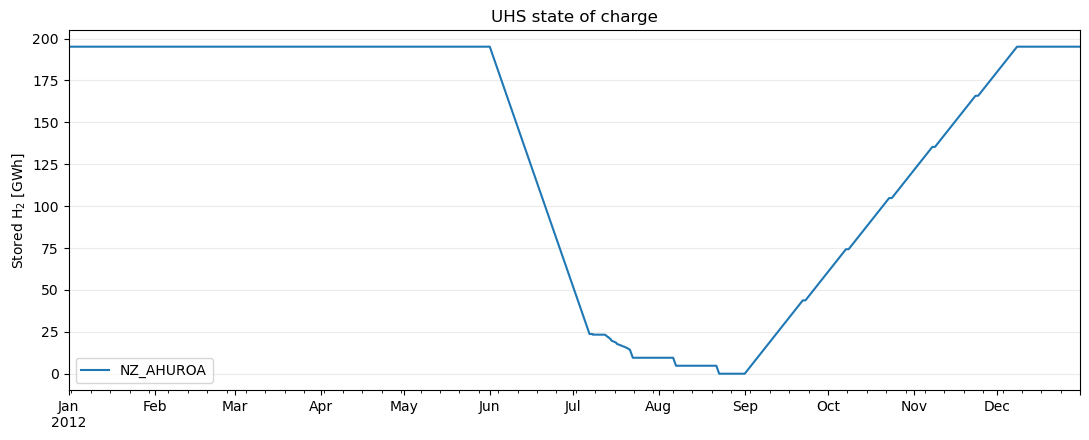

In [40]:
fig, ax = plt.subplots(figsize=(11, 4.5))

for store_name in uhs_stores:
    site_id = store_name.replace(" H2 UHS", "")
    (n.stores_t.e[store_name] / 1e3).plot(ax=ax, label=site_id)

ax.set_ylabel("Stored H$_2$ [GWh]")
ax.set_xlabel("")
ax.set_title("UHS state of charge")
ax.legend(title=None)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

### Injection and withdrawal profile

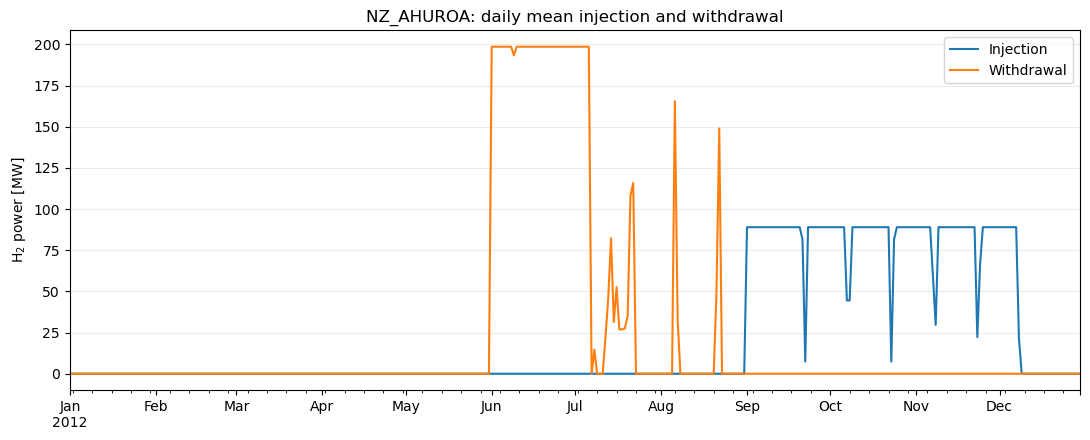

In [41]:
# Daily averages make the seasonal operating pattern easier to read than 8,760 hourly points.
site_id = uhs_stores[0].replace(" H2 UHS", "")
inj_name = f"{site_id} H2 injection"
wd_name = f"{site_id} H2 withdrawal"

uhs_power = pd.DataFrame(
    {
        "Injection": n.links_t.p0[inj_name],
        "Withdrawal": n.links_t.p0[wd_name],
    },
    index=n.snapshots,
)

daily_uhs_power = uhs_power.resample("D").mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
daily_uhs_power.plot(ax=ax)
ax.set_ylabel("H$_2$ power [MW]")
ax.set_xlabel("")
ax.set_title(f"{site_id}: daily mean injection and withdrawal")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

### Hydrogen storage portfolio

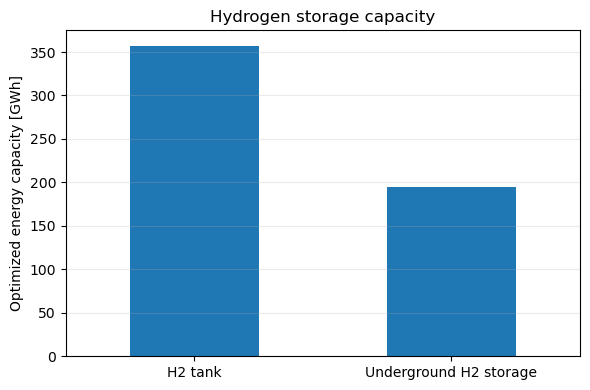

,GWh
carrier,
H2 tank,357.077
Underground H2 storage,195.169


In [42]:
h2_storage_capacity = (
    n.stores.loc[n.stores.carrier.isin(["H2 Store Tank", "H2 UHS"])]
    .groupby("carrier")["e_nom_opt"]
    .sum()
    .div(1e3)
    .rename(
        {
            "H2 Store Tank": "H2 tank",
            "H2 UHS": "Underground H2 storage",
        }
    )
)

ax = h2_storage_capacity.plot.bar(figsize=(6, 4), rot=0)
ax.set_ylabel("Optimized energy capacity [GWh]")
ax.set_xlabel("")
ax.set_title("Hydrogen storage capacity")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

h2_storage_capacity.to_frame("GWh").round(3)

### Baseline vs UHS

In [43]:
def network_summary(net):
    """Compact metrics for comparing the baseline and UHS solutions."""
    h2_tank = net.stores.loc[net.stores.carrier.eq("H2 Store Tank"), "e_nom_opt"].sum()
    h2_uhs = net.stores.loc[net.stores.carrier.eq("H2 UHS"), "e_nom_opt"].sum()

    electrolysis = net.links.loc[
        net.links.carrier.eq("H2 Electrolysis"), "p_nom_opt"
    ].sum()

    h2_pipeline = net.links.loc[
        net.links.carrier.astype(str).str.contains("H2 pipeline", regex=False),
        "p_nom_opt",
    ].sum()

    return pd.Series(
        {
            "Objective [EUR/a]": float(net.objective),
            "H2 tank [GWh]": h2_tank / 1e3,
            "UHS [GWh]": h2_uhs / 1e3,
            "Electrolysis [MW]": electrolysis,
            "H2 pipeline [MW]": h2_pipeline,
        }
    )

if baseline_path.exists():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    n_base = pypsa.Network(str(baseline_path))
    warnings.simplefilter(action="default", category=FutureWarning)

    comparison = pd.concat(
        {
            "Baseline": network_summary(n_base),
            "With UHS": network_summary(n),
        },
        axis=1,
    )
    comparison["Difference"] = comparison["With UHS"] - comparison["Baseline"]
    comparison["Difference [%]"] = (
        100 * comparison["Difference"] / comparison["Baseline"].replace(0, np.nan)
    )

    display(comparison.round(3))
else:
    print(f"Baseline not found: {baseline_path}")
    print("Copy the frozen _BASE.nc file there to enable this comparison.")

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L0.40-1h_1h_2030_0.071.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


,Baseline,With UHS,Difference,Difference [%]
Objective [EUR/a],3.634093e+09,3.634093e+09,0.0,0.0
H2 tank [GWh],3.570770e+02,3.570770e+02,0.0,0.0
UHS [GWh],1.951690e+02,1.951690e+02,0.0,0.0
Electrolysis [MW],4.210071e+03,4.210071e+03,0.0,0.0
H2 pipeline [MW],3.893670e+02,3.893670e+02,0.0,0.0


### Interpretation checklist

For the first UHS validation, check that:

1. Ahuroa has non-zero optimized energy and power capacities.
2. Its optimized capacities do not exceed the site maxima from `uhs_sites.csv`.
3. The state of charge varies through the year and closes consistently under the cyclic-store constraint.
4. Injection and withdrawal are both used and the compression-electricity demand is non-zero.
5. `annual_withdrawal_over_capacity` is interpreted only as an **equivalent throughput ratio**; it does not count actual geological/operational cycles.
6. `operating_direction_switches` helps diagnose whether the optimizer is reversing frequently between injection and withdrawal, which is the more relevant signal for designing a seasonal-cycling constraint.
7. The baseline comparison shows which parts of the H₂ system are displaced or expanded when UHS is available.

Only after these checks are consistent is it useful to move on to multiple UHS sites or global datasets.

## Analyse pv and wind potential - map view

In [44]:
solar = xr.open_dataset(str(solar_path))
wind = xr.open_dataset(str(onwind_path))

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br_path = PARENT / "resources" / scenario_name / "bus_regions" / f"regions_{voronoi}.geojson"
    br = gpd.read_file(str(br_path))
    br = clean_geometries(br)
    br = br.set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, links, loads, storage_units, transformers


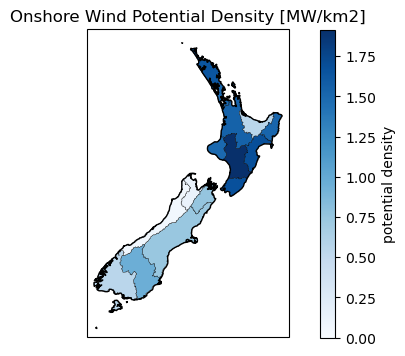

In [45]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(str(network_path)),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, links, loads, storage_units, transformers


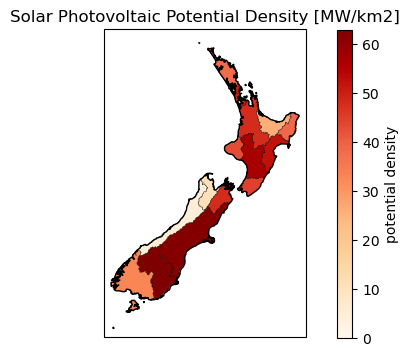

In [46]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(str(network_path)),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)